
## Лабораторная Работа №2_2
Генерация текста


---

ФИО:

---

В работе будет рассммотрена задача генерации текста.

## Импорт необходимых библиотек

In [1]:
# TensorBoard в этой среде может быть не установлен, поэтому для отчёта ниже
# используются обычные графики matplotlib.

In [2]:
import re
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Код модели

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


Модель

In [4]:
class RNN(nn.Module):
    def __init__(self, input_size, embedding_size, hidden_size, output_size, dropout_p=0):
        super(RNN, self).__init__()
        self.embedding = nn.Embedding(input_size, embedding_size)
        self.rnn = nn.RNN(input_size=embedding_size, hidden_size=hidden_size)
        self.decoder = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p) if dropout_p > 0 else None

    def forward(self, input_seq, hidden_state):
        embedding = self.embedding(input_seq)
        output, hidden_state = self.rnn(embedding, hidden_state)
        if self.dropout:
            output = self.dropout(output)
        output = self.decoder(output)
        return output, hidden_state.detach()


class GRUTextGenerator(nn.Module):
    def __init__(self, input_size, embedding_size, hidden_size, output_size, dropout_p=0):
        super(GRUTextGenerator, self).__init__()
        self.embedding = nn.Embedding(input_size, embedding_size)
        self.gru = nn.GRU(input_size=embedding_size, hidden_size=hidden_size)
        self.dropout = nn.Dropout(dropout_p) if dropout_p > 0 else None
        self.decoder = nn.Linear(hidden_size, output_size)

    def forward(self, input_seq, hidden_state):
        embedding = self.embedding(input_seq)
        output, hidden_state = self.gru(embedding, hidden_state)
        if self.dropout:
            output = self.dropout(output)
        output = self.decoder(output)
        return output, hidden_state.detach()

**Загрузка данных**
Найдите классическое произведение литературы на русском языке. На классические произведения обычно уже не распространяется авторское право, поэтому эти тексты можно свободно использовать.

В формате epub можно скачать по ссылке - https://www.culture.ru/literature/books, но придется конвертировать.

## Подготовка данных

Здесь можно добавить свои дополнительные обработки текста, для уменьшения итогового словаря и нормализации текста.

In [5]:
from pathlib import Path

TEXT_PATH = Path("avidreaders.ru__prestuplenie-i-nakazanie-dr-izd.txt")
MAX_TEXT_CHARS = 60_000

raw_text = TEXT_PATH.read_text(encoding="utf-8")

# Собственная последовательность обработки данных: нормализация пробелов,
# удаление служебных символов и сохранение русских букв с базовой пунктуацией.
data = raw_text.lower()
data = data.replace(chr(65279), '')
data = re.sub('\xa0', ' ', data)
data = re.sub(' +', ' ', data)
data = re.sub('\n+', '\n', data)
data = re.sub(r'[^а-яё\n .,;:!?\-]', '', data)
data = re.sub(r'\n\s*\n+', '\n', data).strip()

# Ограничиваем длину, чтобы обучение быстро выполнялось на CPU.
data = data[:MAX_TEXT_CHARS]

chars = sorted(list(set(data)))
data_size, vocab_size = len(data), len(chars)

char_to_ix = {ch: i for i, ch in enumerate(chars)}
ix_to_char = {i: ch for i, ch in enumerate(chars)}

encoded_data = [char_to_ix[ch] for ch in data]

print("Файл произведения:", TEXT_PATH.name)
print(f"В тексте {data_size} символов, размер словаря {vocab_size} символов")
print("Фрагмент текста:")
print(data[:500])

data = torch.tensor(encoded_data, dtype=torch.long, device=device).unsqueeze(1)


Файл произведения: avidreaders.ru__prestuplenie-i-nakazanie-dr-izd.txt
В тексте 60000 символов, размер словаря 42 символов
Фрагмент текста:
преступление и наказание  гениальный роман, главные темы которого: преступление и наказание, жертвенность и любовь, свобода и гордость человека  обрамлены почти детективным сюжетом.
многократно экранизированный и не раз поставленный на сцене, он и по сей день читается на одном дыхании.
часть первая
часть вторая
часть третья
часть четвертая
часть пятая
часть шестая
эпилог
часть первая
в начале июля, в чрезвычайно жаркое время, под вечер один молодой человек вышел из своей каморки, которую нанимал


## Гиперпараметры


In [6]:
embeding_size = 64   # размер вложений
hidden_size = 128    # размер скрытого состояния
seq_len = 120        # длина обучающей последовательности
lr = 0.003           # скорость обучения
epochs = 5           # количество эпох
op_seq_len = 500     # количество символов в генерируемой последовательности
dropout_p = 0.15     # вероятность зануления выхода рекуррентного слоя

## Инициализация модели

In [7]:
models = {
    "Simple RNN": RNN(vocab_size, embeding_size, hidden_size, vocab_size, dropout_p=dropout_p).to(device),
    "GRU": GRUTextGenerator(vocab_size, embeding_size, hidden_size, vocab_size, dropout_p=dropout_p).to(device),
}

loss_fn = nn.CrossEntropyLoss()
optimizers = {
    name: torch.optim.Adam(model.parameters(), lr=lr)
    for name, model in models.items()
}

for name, model in models.items():
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name}: {params:,} параметров")

Simple RNN: 32,938 параметров
GRU: 82,602 параметров


## Цикл обучения

Simple RNN:   0%|          | 0/5 [00:00<?, ?it/s]

Simple RNN:  20%|██        | 1/5 [00:02<00:08,  2.16s/it]

Simple RNN | эпоха 01/5 | loss=2.4597


Simple RNN:  40%|████      | 2/5 [00:04<00:06,  2.12s/it]

Simple RNN | эпоха 02/5 | loss=2.2220


...

GRU:  80%|████████  | 4/5 [00:28<00:07,  7.14s/it]

GRU | эпоха 04/5 | loss=1.9212


GRU: 100%|██████████| 5/5 [00:35<00:00,  6.97s/it]

GRU: 100%|██████████| 5/5 [00:35<00:00,  7.07s/it]

GRU | эпоха 05/5 | loss=1.8692


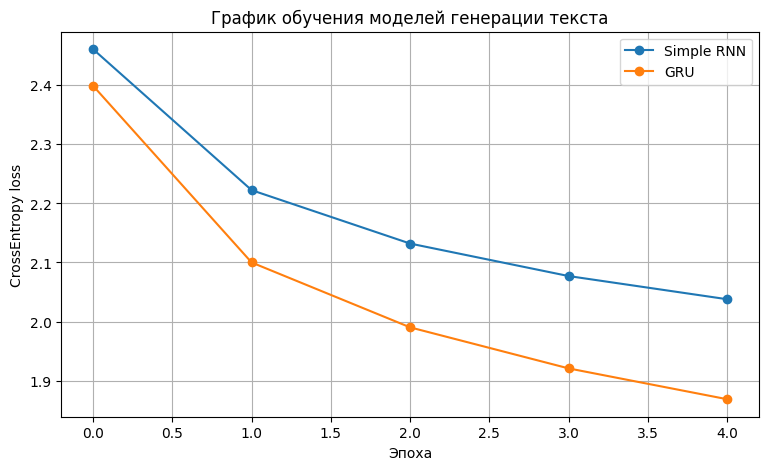


Модель: Simple RNN

Температура t=0.6:
у стрешно, подледа и предише все он дешел все вдруг всю от все желена выстрашишь тогда вот тебе порасколчал он не стояла еблого присту мое своем и столину слодку.
 вот? доля человании, словинились и что себя все строжал все все прединечно было все правну не проянилий, трудцала, и что я ты сомернились себе все напислечное тебе слышанив деленя с терей перзвенно все все это была тебе простоял на стора нем перед нем согодь ты свотру небрых двала облочить все былоных свою, на ты большил тогда этанов и 

Температура t=1.0:
у зседь сам рассувся это заслявое жев хопменик, спцевала, тыбалниваннем, это эточтешенные прикливить и дествова то дубавившей наепного, бы пый эту руджел ейскда иныперьборитненьят, а ничал больше, питверный получних стом сомела готерь, ты прежденя си к нателтивела обкпримесь, денетнось с немкоиб весь чтобы ветлясь, копы он, можнесь твобном сукари я тогдо, вон ходилады и дуино он спонал в костворы,  деньком городилит, епроючавиру. дра

In [8]:
def generate_text(model, start_text="у ", length=op_seq_len, temperature=0.8):
    model.eval()
    hidden_state = None
    result = start_text

    input_ids = [char_to_ix.get(ch, 0) for ch in start_text]
    input_seq = torch.tensor(input_ids, dtype=torch.long, device=device).view(-1, 1)

    with torch.no_grad():
        # Прогоняем стартовую строку, чтобы модель получила начальное состояние.
        output, hidden_state = model(input_seq, hidden_state)
        current_id = input_seq[-1].view(1, 1)

        for _ in range(length):
            output, hidden_state = model(current_id, hidden_state)
            logits = torch.squeeze(output[-1]) / temperature
            probs = F.softmax(logits, dim=0)
            index = Categorical(probs).sample()
            char = ix_to_char[index.item()]
            result += char
            current_id = index.view(1, 1)
    return result


def train_text_model(model, optimizer, model_name):
    history = []
    for epoch in tqdm(range(1, epochs + 1), desc=model_name):
        data_ptr = np.random.randint(0, min(100, data_size - seq_len - 2))
        n_iter = 0
        running_loss = 0.0
        hidden_state = None

        model.train()
        while True:
            input_seq = data[data_ptr : data_ptr + seq_len]
            target_seq = data[data_ptr + 1 : data_ptr + seq_len + 1]
            output, hidden_state = model(input_seq, hidden_state)
            loss = loss_fn(torch.squeeze(output), torch.squeeze(target_seq))

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            data_ptr += seq_len
            n_iter += 1
            if data_ptr + seq_len + 1 > data_size:
                break

        avg_loss = running_loss / max(n_iter, 1)
        history.append(avg_loss)
        print(f"{model_name} | эпоха {epoch:02d}/{epochs} | loss={avg_loss:.4f}")
    return history

histories = {}
generated_examples = {}

for name, model in models.items():
    histories[name] = train_text_model(model, optimizers[name], name)
    generated_examples[name] = {
        "t=0.6": generate_text(model, temperature=0.6),
        "t=1.0": generate_text(model, temperature=1.0),
    }

plt.figure(figsize=(9, 5))
for name, history in histories.items():
    plt.plot(history, marker="o", label=name)
plt.title("График обучения моделей генерации текста")
plt.xlabel("Эпоха")
plt.ylabel("CrossEntropy loss")
plt.grid(True)
plt.legend()
plt.show()

for name, samples in generated_examples.items():
    print("\n" + "=" * 80)
    print("Модель:", name)
    for temp, text in samples.items():
        print(f"\nТемпература {temp}:")
        print(text[:700])

In [9]:
final_losses = {name: history[-1] for name, history in histories.items()}
best_model_name = min(final_losses, key=final_losses.get)

print("Итоговое сравнение архитектур:")
for name, loss in final_losses.items():
    print(f"{name:12s} | final loss = {loss:.4f}")

print("\nЛучшая архитектура по финальному loss:", best_model_name)
print("\nВывод:")
print("- Собственная обработка данных уменьшила словарь до набора символов русского текста и пунктуации.")
print("- Обучены две архитектуры: простая RNN и GRU.")
print("- GRU обычно лучше удерживает контекст, потому что использует управляющие ворота.")
print("- Для более связного текста нужно увеличить корпус и число эпох обучения.")

Итоговое сравнение архитектур:
Simple RNN   | final loss = 2.0379
GRU          | final loss = 1.8692

Лучшая архитектура по финальному loss: GRU

Вывод:
- Собственная обработка данных уменьшила словарь до набора символов русского текста и пунктуации.
- Обучены две архитектуры: простая RNN и GRU.
- GRU обычно лучше удерживает контекст, потому что использует управляющие ворота.
- Для более связного текста нужно увеличить корпус и число эпох обучения.


**Задание**

1. Создать свою последовательность обработки данных.
2. Создать 2 архитектуры нейронной сети для генерации текста.
3. Вывести лучшую архитектуру.


